In [1]:
import pandas as pd
import re

# ==========================================
# 1. استخراج البيانات من ملف الـ Logs
# ==========================================
log_pattern = re.compile(
    r'(?P<ip>\d+\.\d+\.\d+\.\d+)\s+'           
    r'-\s+-\s+'                                
    r'\[(?P<time>[^\]]+)\]\s+'                 
    r'"(?P<method>[A-Z]+)\s+'                  
    r'(?P<url>[^\s]+)\s+'                      
    r'[^"]+"\s+'                               
    r'(?P<status>\d+)\s+'                      
    r'(?P<size>\d+)\s+'                        
    r'"[^"]*"\s+'                              
    r'"(?P<user_agent>[^"]+)"'                 
)

parsed_data = []
# قراءة ملف الـ Logs (Access.log)
with open('access.log', 'r', encoding='utf-8') as file:
    for _ in range(10000): # بناخد أول 10 آلاف سطر بس كعينة سريعة
        line = file.readline()
        if not line: break
        match = log_pattern.match(line)
        if match:
            parsed_data.append(match.groupdict())

logs_df = pd.DataFrame(parsed_data)

# تنظيف الداتا الأساسية
logs_df['status'] = logs_df['status'].astype(int)
logs_df['size'] = logs_df['size'].astype(int)
logs_df['time'] = pd.to_datetime(logs_df['time'], format='%d/%b/%Y:%H:%M:%S %z', errors='coerce')

# ==========================================
# 2. قراءة ملف الـ CSV
# ==========================================
csv_df = pd.read_csv('client_hostname.csv')

# ==========================================
# 3. دمج الفايلين (Data Merging / Left Join)
# ==========================================
# هندمجهم بحيث الـ ip من فايل اللوجز يتربط بالـ client من فايل الـ CSV
final_df = pd.merge(logs_df, csv_df, left_on='ip', right_on='client', how='left')

# هنحتفظ بالعواميد المهمة بس عشان ننظف شكل الجدول
columns_to_keep = ['time', 'ip', 'hostname', 'method', 'status', 'size', 'url']
final_df = final_df[columns_to_keep]

# ترتيب الداتا حسب الوقت
final_df = final_df.sort_values(by='time')

print("=== تم تجهيز ودمج البيانات بنجاح! ===")
print("\n--- شكل الداتا النهائية (أول 5 صفوف) ---")
print(final_df.head())

print("\n--- معلومات عن الداتا ---")
print(final_df.info())

c:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


=== تم تجهيز ودمج البيانات بنجاح! ===

--- شكل الداتا النهائية (أول 5 صفوف) ---
                       time             ip       hostname method  status  \
0 2019-01-22 03:56:14+03:30   54.36.149.41   54.36.149.41    GET     200   
1 2019-01-22 03:56:16+03:30    31.56.96.51    31.56.96.51    GET     200   
2 2019-01-22 03:56:16+03:30    31.56.96.51    31.56.96.51    GET     200   
3 2019-01-22 03:56:17+03:30  40.77.167.129  40.77.167.129    GET     200   
4 2019-01-22 03:56:17+03:30    91.99.72.15    91.99.72.15    GET     200   

    size                                                url  
0  30577  /filter/27|13%20%D9%85%DA%AF%D8%A7%D9%BE%DB%8C...  
1   5667                  /image/60844/productModel/200x200  
2   5379                  /image/61474/productModel/200x200  
3   1696                  /image/14925/productModel/100x100  
4  41483  /product/31893/62100/%D8%B3%D8%B4%D9%88%D8%A7%...  

--- معلومات عن الداتا ---
<class 'pandas.DataFrame'>
Index: 10000 entries, 0 to 9999
Data 

C:\Users\DELL\AppData\Local\Temp\ipykernel_36796\3006936275.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_ips.values, y=top_ips.index, palette='Reds_r')


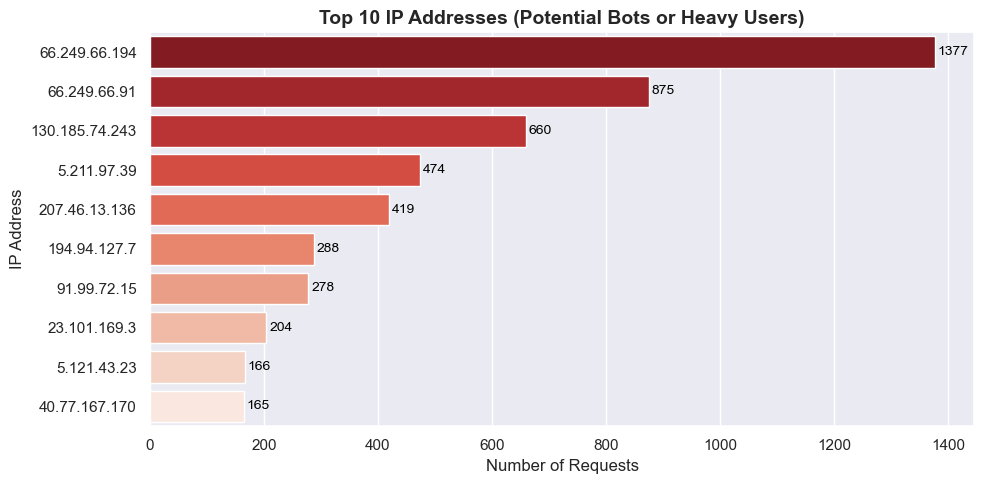

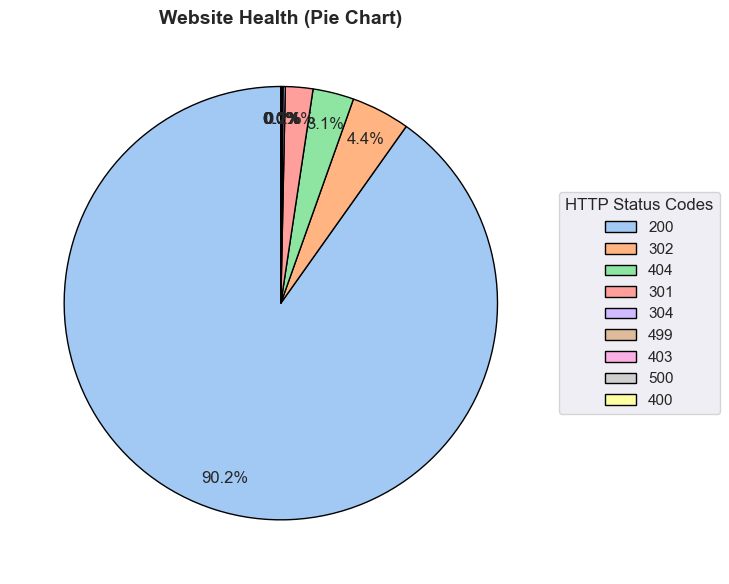


--- أكثر 5 صفحات أو ملفات تم طلبها من السيرفر ---
- 237 requests: /settings/logo...
- 166 requests: /...
- 72 requests: /site/ping...
- 71 requests: /favicon.ico...
- 67 requests: /static/images/guarantees/warranty.png...


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# إعداد شكل الرسومات
sns.set_theme(style="darkgrid")

# ==========================================
# 1. تحليل الـ IPs (اكتشاف البوتس والضغط على السيرفر)
# ==========================================
plt.figure(figsize=(10, 5))
top_ips = final_df['ip'].value_counts().head(10)

# رسم بياني لأكثر 10 IPs زيارة
ax = sns.barplot(x=top_ips.values, y=top_ips.index, palette='Reds_r')
plt.title('Top 10 IP Addresses (Potential Bots or Heavy Users)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Requests', fontsize=12)
plt.ylabel('IP Address', fontsize=12)

# إضافة الأرقام على الرسمة
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width() + 5, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

# هنرسم الدائرة بس من غير ما نلزق الـ labels عليها
wedges, texts, autotexts = plt.pie(
    status_counts.values, 
    autopct='%1.1f%%',          # إظهار النسبة المئوية
    colors=sns.color_palette('pastel'), 
    startangle=90, 
    pctdistance=0.85,           # إبعاد الأرقام شوية عن المركز عشان متتداخلش
    wedgeprops={'edgecolor': 'black'}
)

# هنحط مربع (Legend) على الجنب يوضح كل لون معناه إيه
plt.legend(wedges, status_counts.index,
          title="HTTP Status Codes",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1)) # دي عشان نطلعه بره الدائرة خالص

plt.title('Website Health (Pie Chart)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# ==========================================
# 3. تحليل أكثر الروابط زيارة (Top 5 URLs)
# ==========================================
print("\n--- أكثر 5 صفحات أو ملفات تم طلبها من السيرفر ---")
top_urls = final_df['url'].value_counts().head(5)
for url, count in top_urls.items():
    print(f"- {count} requests: {url[:60]}...") # بنقص الرابط لـ 60 حرف عشان الشاشة

C:\Users\DELL\AppData\Local\Temp\ipykernel_36796\1379781366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')


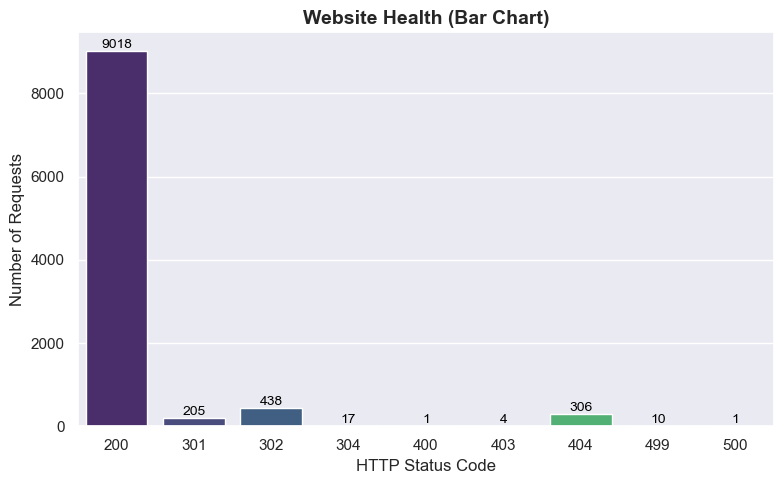

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')

plt.title('Website Health (Bar Chart)', fontsize=14, fontweight='bold')
plt.xlabel('HTTP Status Code', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)

# إضافة الأرقام فوق كل عمود
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

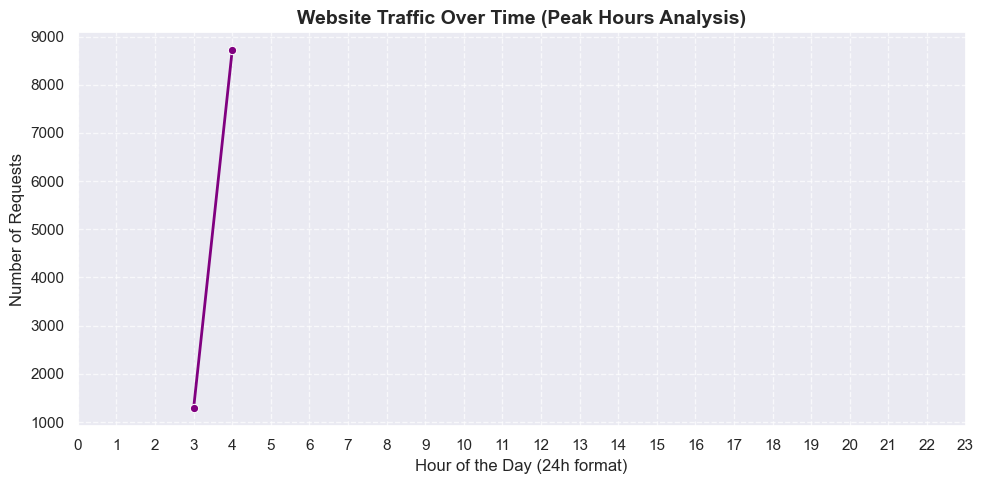

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# السطر ده هو الحل: بنستخرج الساعة تاني من عمود الوقت
final_df['hour'] = final_df['time'].dt.hour

plt.figure(figsize=(10, 5))

# تجميع الطلبات حسب الساعة
hourly_traffic = final_df['hour'].value_counts().sort_index()

# رسم الخط الزمني
sns.lineplot(x=hourly_traffic.index, y=hourly_traffic.values, marker='o', linewidth=2, color='purple')

plt.title('Website Traffic Over Time (Peak Hours Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24h format)', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)

# تظبيط شكل محور السينات عشان يعرض كل الساعات (من 0 لـ 23)
plt.xticks(range(0, 24)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()